In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os


feature_path = os.path.abspath(r"C:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor")
# feature_path = os.path.abspath('/Users/alexg/Documents/Documents/Prize-Picks-Prop-Predictor')
if feature_path not in sys.path:
    sys.path.append(feature_path)

from FEATURE_ENGINEERING.features import *
from PROPS_EV.calculateEVS import *
from BACKTEST.backtest import *
from MODELS.Models import *

In [2]:
model = joblib.load('../MODELS/Models/xgbModel.pkl')
features = joblib.load('../MODELS/Models/top_features.pkl')

In [3]:
pd.set_option('display.max_columns', None)
eplison = 0.000001

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s25['EXPECTED_USAGE_MIN'] = s25['USG_PCT_ROLLING_AVG_5'] * (s25['MIN_ROLLING_AVG_5'] + eplison)
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s24['EXPECTED_USAGE_MIN'] = s24['USG_PCT_ROLLING_AVG_5'] * (s24['MIN_ROLLING_AVG_5'] + eplison)

df = pd.concat([s25, s24]).sort_values(by='GAME_DATE')

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['CATEGORY'] == 'player_points') & (backtestData['BOOKMAKER'] == 'prizepicks')]
backtestData

C:\Users\alexg\AppData\Local\Temp\ipykernel_1880\234261984.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
0,0,0,0,Miles McBride,player_points,prizepicks,under,8.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
3,3,3,3,Jayson Tatum,player_points,prizepicks,over,26.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
4,4,4,4,Jayson Tatum,player_points,prizepicks,under,26.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
5,5,5,5,Jalen Brunson,player_points,prizepicks,over,27.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
6,6,6,6,Jalen Brunson,player_points,prizepicks,under,27.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198078,198078,198078,119117,Blake Wesley,player_points,prizepicks,under,9.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,9.5,-108.0,under
198083,198083,198083,119122,Malaki Branham,player_points,prizepicks,over,11.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,12.5,100.0,over
198089,198089,198089,119128,Malaki Branham,player_points,prizepicks,under,11.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,12.5,100.0,under
198095,198095,198095,119134,Garrett Temple,player_points,prizepicks,under,9.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,9.5,-115.0,under


In [5]:
results = backtestPrizePicks3Legs(df, backtestData, '2025-03-21', model, features, edge_threshold=4.5, top_n=10, simulations=10000)
results

Processing 3-leg parlays...


,player1,player2,player3,side1,side2,side3,model_side1,model_side2,model_side3,line1,line2,line3,pred1,pred2,pred3,actual1,actual2,actual3,edge1,edge2,edge3,leg1_won,leg2_won,leg3_won,parlay_recommendation,parlay_won,ev_percent,probability,date
0,A.J. Lawson,Bronny James,Gabe Vincent,over,over,over,UNDER,OVER,UNDER,10.5,6.5,14.5,3.07,10.99,7.18,0,17,9,-7.43,4.49,-7.32,1,1,1,0,1,4.677,0.9462,2025-03-21
1,Bronny James,Franz Wagner,Gabe Vincent,over,over,over,OVER,UNDER,UNDER,6.5,24.5,14.5,10.99,17.18,7.18,17,21,9,4.49,-7.32,-7.32,1,1,1,0,1,4.406,0.9010,2025-03-21
2,A.J. Lawson,Austin Reaves,Bronny James,over,over,over,UNDER,UNDER,OVER,10.5,30.5,6.5,3.07,21.94,10.99,0,22,17,-7.43,-8.56,4.49,1,1,1,0,1,4.368,0.8946,2025-03-21
3,A.J. Lawson,Austin Reaves,Gabe Vincent,over,over,over,UNDER,UNDER,UNDER,10.5,30.5,14.5,3.07,21.94,7.18,0,22,9,-7.43,-8.56,-7.32,1,1,1,1,1,4.367,0.8945,2025-03-21
4,A.J. Lawson,Franz Wagner,Gabe Vincent,over,over,over,UNDER,UNDER,UNDER,10.5,24.5,14.5,3.07,17.18,7.18,0,21,9,-7.43,-7.32,-7.32,1,1,1,1,1,4.321,0.8868,2025-03-21
5,A.J. Lawson,Bronny James,Franz Wagner,over,over,over,UNDER,OVER,UNDER,10.5,6.5,24.5,3.07,10.99,17.18,0,17,21,-7.43,4.49,-7.32,1,1,1,0,1,4.321,0.8869,2025-03-21
6,Bronny James,Gabe Vincent,Julian Phillips,over,over,over,OVER,UNDER,OVER,6.5,14.5,6.5,10.99,7.18,8.84,17,9,2,4.49,-7.32,2.34,1,1,0,0,0,4.123,0.8539,2025-03-21
7,Austin Reaves,Franz Wagner,Gabe Vincent,over,over,over,UNDER,UNDER,UNDER,30.5,24.5,14.5,21.94,17.18,7.18,22,21,9,-8.56,-7.32,-7.32,1,1,1,1,1,4.111,0.8518,2025-03-21
8,Austin Reaves,Bronny James,Franz Wagner,over,over,over,UNDER,OVER,UNDER,30.5,6.5,24.5,21.94,10.99,17.18,22,17,21,-8.56,4.49,-7.32,1,1,1,0,1,4.111,0.8519,2025-03-21
9,A.J. Lawson,Bronny James,Dalton Knecht,over,over,over,UNDER,OVER,UNDER,10.5,6.5,22.5,3.07,10.99,14.86,0,17,17,-7.43,4.49,-7.64,1,1,1,0,1,4.085,0.8475,2025-03-21


In [9]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPrizePicks3Legs(df, backtestData, date, model, features, edge_threshold=5, top_n=10, simulations=10000)
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-23... 1/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-10-24... 2/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-10-25... 3/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-10-26... 4/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-10-27... 5/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-10-28... 6/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-10-29... 7/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-10-30... 8/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-10-31... 9/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-11-01... 10/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-11-02... 11/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-11-03... 12/162
Processing 3-leg parlays...
  ✓ Processed 10 bets
Processing 2024-11-04... 

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,410
   Wins: 569
   Hit Rate: 40.35%
   Total Profit: $10,020.00
   Total Staked: $7,050.00
   ROI: 142.13%
   Volatility: $102.08
   Max Drawdown: $-150.00
   Sharpe Ratio: 8.267

 RECOMMENDED BETS ANALYSIS (Edge > 5):
   Total Bets: 216
   Wins: 103
   Hit Rate: 47.69%
   Total Profit: $2,010.00
   Total Staked: $1,080.00
   ROI: 186.11%
   Volatility: $42.73
   Max Drawdown: $-55.00
   Sharpe Ratio: 5.583


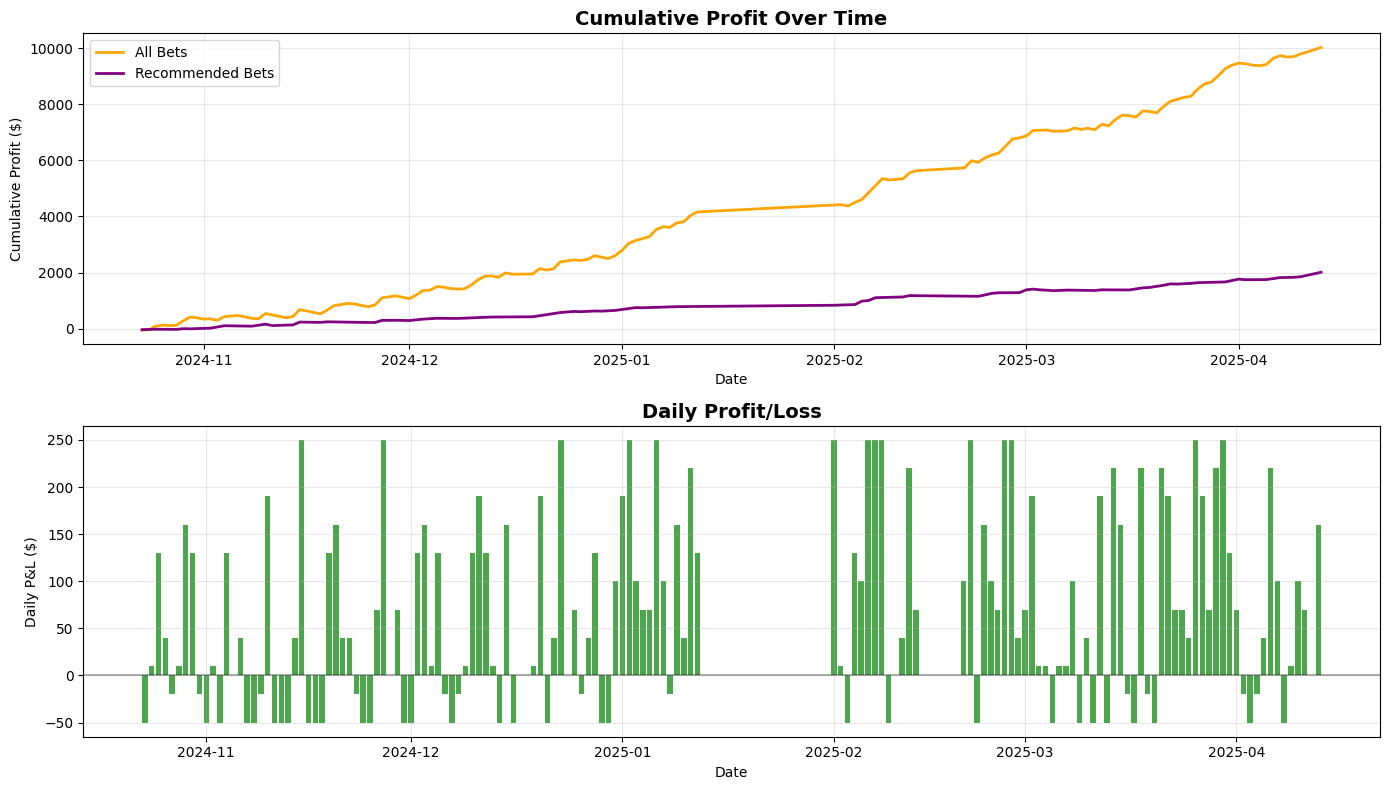

In [11]:
# Calculate metrics for all 3-leg bets
all_metrics = calculate3LegMetrics(final_results, stake=5)
edge = 5

# Calculate metrics for recommended 3-leg bets only (edge > threshold)
recommended_3legs = final_results[final_results['parlay_recommendation'] == 1]
rec_metrics = calculate3LegMetrics(recommended_3legs, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > {edge}):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()